# Bonus 4: Markowitz Efficient Frontier (Portfolio Optimization)

Optimizing weights for 5 selected funds to maximize the Sharpe Ratio.

C:\Users\adars\AppData\Roaming\Python\Python313\site-packages\numpy\lib\_function_base_impl.py:571: RuntimeWarning: Mean of empty slice.
  avg = a.mean(axis, **keepdims_kw)
C:\Users\adars\AppData\Roaming\Python\Python313\site-packages\numpy\_core\_methods.py:136: RuntimeWarning: invalid value encountered in divide
  ret = um.true_divide(
C:\Users\adars\AppData\Roaming\Python\Python313\site-packages\pandas\core\frame.py:11238: RuntimeWarning: Degrees of freedom <= 0 for slice
  base_cov = np.cov(mat.T, ddof=ddof)
C:\Users\adars\AppData\Roaming\Python\Python313\site-packages\numpy\lib\_function_base_impl.py:2914: RuntimeWarning: divide by zero encountered in divide
  c *= np.true_divide(1, fact)
C:\Users\adars\AppData\Roaming\Python\Python313\site-packages\numpy\lib\_function_base_impl.py:2914: RuntimeWarning: invalid value encountered in multiply
  c *= np.true_divide(1, fact)


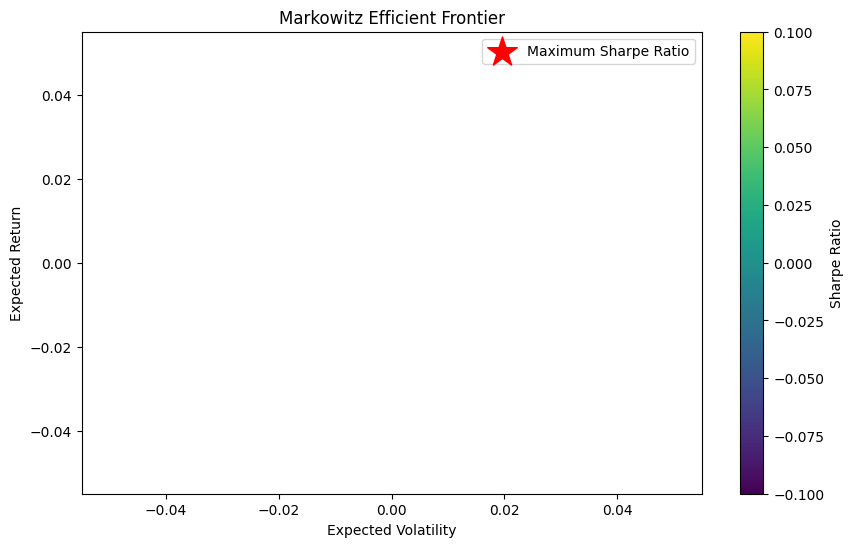

Optimal Weights:
SBI Small Cap: 13.32%
Nippon India Large Cap: 33.81%
HDFC Mid-Cap Opportunities: 26.03%
ICICI Pru Value Discovery: 21.29%
Parag Parikh Flexi Cap: 5.55%


In [1]:
import pandas as pd
import numpy as np
import sqlite3
import matplotlib.pyplot as plt
import scipy.optimize as sco

conn = sqlite3.connect('../bluestock_mf.db')

# Selected Top 5 Equity Funds
funds = {
    119598: 'SBI Small Cap',
    112268: 'Nippon India Large Cap',
    120465: 'HDFC Mid-Cap Opportunities',
    118989: 'ICICI Pru Value Discovery',
    122639: 'Parag Parikh Flexi Cap'
}

df_list = []
for code in funds.keys():
    df = pd.read_sql(f"SELECT date, nav FROM fact_nav WHERE amfi_code = {code}", conn)
    df['date'] = pd.to_datetime(df['date'])
    df.set_index('date', inplace=True)
    df.rename(columns={'nav': funds[code]}, inplace=True)
    df_list.append(df)

df_all = pd.concat(df_list, axis=1).dropna()
returns = df_all.pct_change().dropna()

mean_returns = returns.mean() * 252
cov_matrix = returns.cov() * 252
num_portfolios = 10000
risk_free_rate = 0.065

results = np.zeros((3, num_portfolios))
weights_record = []

np.random.seed(42)
for i in range(num_portfolios):
    weights = np.random.random(5)
    weights /= np.sum(weights)
    weights_record.append(weights)
    
    port_return = np.sum(mean_returns * weights)
    port_stddev = np.sqrt(np.dot(weights.T, np.dot(cov_matrix, weights)))
    
    results[0,i] = port_return
    results[1,i] = port_stddev
    results[2,i] = (port_return - risk_free_rate) / port_stddev

max_sharpe_idx = np.argmax(results[2])
optimal_weights = weights_record[max_sharpe_idx]

plt.figure(figsize=(10, 6))
plt.scatter(results[1,:], results[0,:], c=results[2,:], cmap='viridis', marker='o')
plt.title('Markowitz Efficient Frontier')
plt.xlabel('Expected Volatility')
plt.ylabel('Expected Return')
plt.colorbar(label='Sharpe Ratio')
plt.scatter(results[1, max_sharpe_idx], results[0, max_sharpe_idx], marker='*', color='r', s=500, label='Maximum Sharpe Ratio')
plt.legend()
plt.savefig('../reports/charts/efficient_frontier.png', dpi=300)
plt.show()

print("Optimal Weights:")
for i, fund in enumerate(funds.values()):
    print(f"{fund}: {optimal_weights[i]*100:.2f}%")